<a href="https://colab.research.google.com/github/Abdullah-Abdualigah/wids-datathon-2026/blob/main/wids_datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

load data from drive

In [248]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


import librarys

In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold,TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import xgboost as xgb

load files

In [250]:
def load_files():
    PATH = '/content/drive/MyDrive/datasets/wids-dataset/'
    meta   = pd.read_csv(PATH + 'metaData.csv')
    sample = pd.read_csv(PATH + 'sample_submission.csv')
    test   = pd.read_csv(PATH + 'test.csv')
    train  = pd.read_csv(PATH + 'train.csv')
    return meta, sample, train, test

meta, sample_submission, train, test = load_files()

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
print(f'\nEvent rate: {train['event'].mean():.4f}')
print(f'time_to_hit range: {train['time_to_hit_hours'].min()} – {train['time_to_hit_hours'].max()}')
print(f'Censored at 72h: {(train['time_to_hit_hours'] == 72).sum()}')


Train shape: (221, 37)
Test  shape: (95, 35)

Event rate: 0.3122
time_to_hit range: 0.0012202119444444 – 66.99447413277778
Censored at 72h: 0


In [251]:
meta.head(50)

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN
8,area_growth_rel_0_5h,feature,growth,Feature from growth category,NaN,NaN
9,area_growth_rate_ha_per_h,feature,growth,Area growth rate (hectares per hour),NaN,NaN


In [252]:
sample_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


In [253]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [254]:
test.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


data dispaly

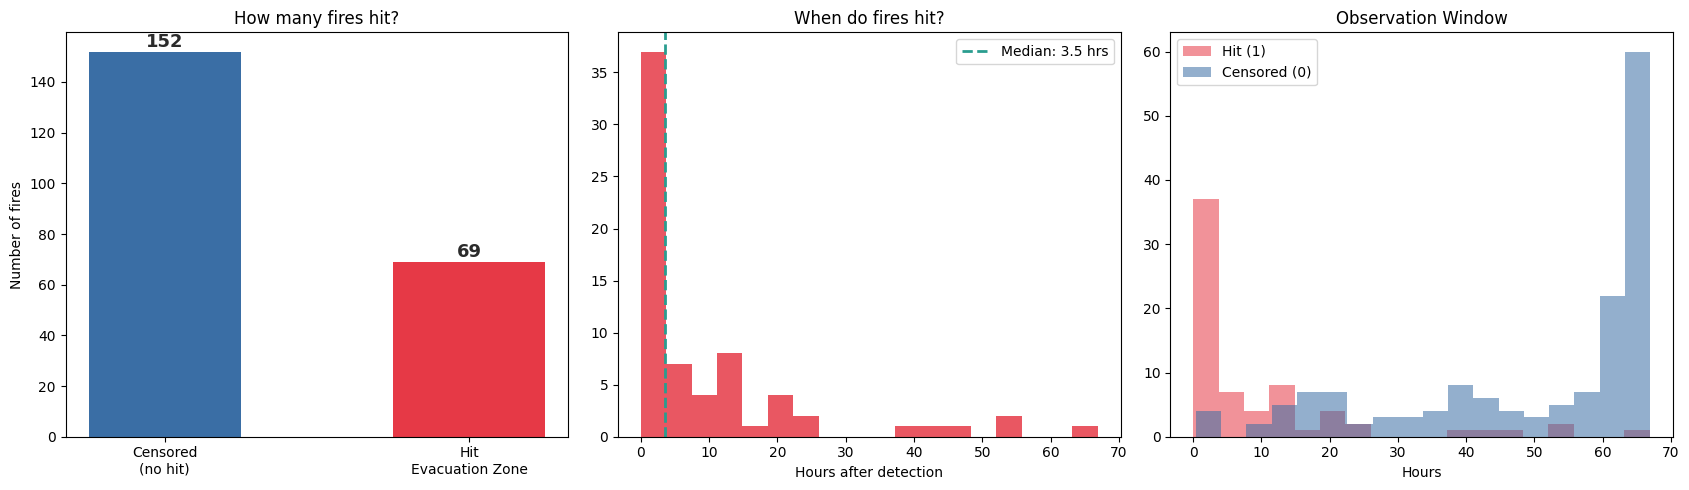

In [255]:
MISS_COLOR  = '#3A6EA5'
HIT_COLOR   = '#E63946'
TEXT_COLOR  = '#2B2B2B'
FIRE_COLOR  = '#2A9D8F'

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

counts = train['event'].value_counts().sort_index()
bars = axes[0].bar(
    ['Censored\n(no hit)', 'Hit\nEvacuation Zone'],
    counts.values,
    color=[MISS_COLOR, HIT_COLOR], edgecolor='none', width=0.5
)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 2,
                 str(cnt), ha='center', color=TEXT_COLOR,
                 fontweight='bold', fontsize=13)
axes[0].set_title('How many fires hit?')
axes[0].set_ylabel('Number of fires')

hits = train[train['event'] == 1]['time_to_hit_hours']
axes[1].hist(hits, bins=18, color=HIT_COLOR, alpha=0.85, edgecolor='none')
axes[1].axvline(hits.median(), color=FIRE_COLOR, ls='--', lw=2,
                label=f'Median: {hits.median():.1f} hrs')
axes[1].set_title('When do fires hit?')
axes[1].set_xlabel('Hours after detection')
axes[1].legend()

for label, color, mask in [
    ('Hit (1)',      HIT_COLOR,  train['event'] == 1),
    ('Censored (0)', MISS_COLOR, train['event'] == 0),
]:
    axes[2].hist(train.loc[mask, 'time_to_hit_hours'], bins=18, alpha=0.55,
                 color=color, label=label, edgecolor='none')
axes[2].set_title('Observation Window')
axes[2].set_xlabel('Hours')
axes[2].legend()

plt.tight_layout()
plt.show()

feature engineering

In [256]:
leaky_cols = ['time_to_contact', 'log_time_to_contact']


def feature_engineering(df):

    data = df.copy()

    speed = data['closing_speed_m_per_h'].clip(lower=0.01)
    dist = data['dist_min_ci_0_5h'].clip(lower=1)

    data['danger_vector'] = data['alignment_abs'] * speed

    data['tracking_urgency'] = data['num_perimeters_0_5h'] * speed

    data['fire_intensity'] = (data['area_growth_rate_ha_per_h'] *
                                data['num_perimeters_0_5h'])

    data['speed_dist_ratio'] = speed / dist

    data['log_dist'] = np.log1p(dist)

    data['hour_sin'] = np.sin(2 * np.pi * data['event_start_hour']/24.0)
    data['hour_cos'] = np.cos(2 * np.pi * data['event_start_hour']/24.0)

    # Clean infinities / NaN
    data = data.replace([np.inf, -np.inf], np.nan).fillna(0)

    return data


In [257]:
train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

In [258]:
base_drop = ['event_id', 'time_to_hit_hours', 'event',
             'event_start_hour', 'event_start_dayofweek']

all_drop_train = base_drop + [c for c in leaky_cols if c in train_fe.columns]
all_drop_test  = ['event_id', 'event_start_hour', 'event_start_dayofweek'] + [c for c in leaky_cols if c in test_fe.columns]

feature_cols = [c for c in train_fe.columns if c not in all_drop_train]
print(f'\nFeatures used ({len(feature_cols)}):', feature_cols)

X_train_full = train_fe[feature_cols]
X_test_full  = test_fe[feature_cols]


Features used (39): ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_month', 'danger_vector', 'tracking_urgency', 'fire_intensity', 'speed_dist_ratio', 'log_dist', 'hour_sin', 'hour_cos']


In [259]:
train_fe = train_fe.sort_values('event_start_hour').reset_index(drop=True)
X_train_full = train_fe[feature_cols]

model xgboost

In [260]:
tscv = TimeSeriesSplit(n_splits=5)

time = [12, 24, 48, 72]

oof_preds   = {h: np.zeros(len(train_fe)) for h in time}
test_preds  = {h: np.zeros(len(test_fe))  for h in time}

for h in time:
    print(f'\n{'='*50}')
    print(f'Horizon H{h}h')
    print(f'{'='*50}')

    y_h = ((train_fe['time_to_hit_hours'] <= h) &
           (train_fe['event'] == 1)).astype(int)
    print(f'Positive rate: {y_h.mean():.4f}  ({y_h.sum()} / {len(y_h)})')

    fold_test_preds = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_full)):
        X_tr,  X_val  = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
        y_tr,  y_val  = y_h.iloc[tr_idx],          y_h.iloc[val_idx]

        scaler = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)
        X_tst_s = scaler.transform(X_test_full)

        neg = (y_tr == 0).sum()
        pos = (y_tr == 1).sum()
        spw = neg / pos if pos > 0 else 1.0

        model = xgb.XGBClassifier(
            n_estimators = 1000,
            learning_rate = 5,
            max_depth = 12,
            scale_pos_weight= spw,
            subsample = 0.8,
            colsample_bytree = 0.8,
            min_child_weight = 5,
            eval_metric = 'logloss',
            early_stopping_rounds = 50,
            random_state = 42,
        )
        model.fit(
            X_tr_s, y_tr,
            eval_set=[(X_val_s, y_val)],
            verbose=False
        )

        oof_preds[h][val_idx] = model.predict_proba(X_val_s)[:, 1]
        fold_test_preds.append(model.predict_proba(X_tst_s)[:, 1])

        print(f'  Fold {fold+1} | best_iter={model.best_iteration} | '
              f'val_pos_rate={y_val.mean():.3f}')

    test_preds[h] = np.mean(fold_test_preds, axis=0)

    oof_binary = (oof_preds[h] >= 0.50).astype(int)
    print(f'\n  OOF Classification Report H{h}:')
    print(classification_report(y_h, oof_binary, digits=3))


Horizon H12h
Positive rate: 0.2217  (49 / 221)
  Fold 1 | best_iter=0 | val_pos_rate=0.278
  Fold 2 | best_iter=0 | val_pos_rate=0.306
  Fold 3 | best_iter=0 | val_pos_rate=0.111
  Fold 4 | best_iter=0 | val_pos_rate=0.306
  Fold 5 | best_iter=0 | val_pos_rate=0.222

  OOF Classification Report H12:
              precision    recall  f1-score   support

           0      0.957     0.901     0.928       172
           1      0.712     0.857     0.778        49

    accuracy                          0.891       221
   macro avg      0.834     0.879     0.853       221
weighted avg      0.902     0.891     0.895       221


Horizon H24h
Positive rate: 0.2851  (63 / 221)
  Fold 1 | best_iter=0 | val_pos_rate=0.389
  Fold 2 | best_iter=0 | val_pos_rate=0.389
  Fold 3 | best_iter=0 | val_pos_rate=0.194
  Fold 4 | best_iter=0 | val_pos_rate=0.361
  Fold 5 | best_iter=0 | val_pos_rate=0.222

  OOF Classification Report H24:
              precision    recall  f1-score   support

           0  

In [261]:
submission_df = pd.DataFrame({
    'event_id' : test['event_id'].values,
    'prob_12h' : test_preds[12],
    'prob_24h' : test_preds[24],
    'prob_48h' : test_preds[48],
    'prob_72h' : test_preds[72],
})

prob_cols = ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
submission_df[prob_cols] = np.maximum.accumulate(
    submission_df[prob_cols].values, axis=1
)

print('\nSubmission preview:')
print(submission_df.head(10).to_string(index=False))
print(f'\nShape: {submission_df.shape}')
print(submission_df[prob_cols].describe())

file_name = 'DSS-JUST.csv'
submission_df.to_csv(file_name, index=False)


Submission preview:
 event_id  prob_12h  prob_24h  prob_48h  prob_72h
 10662602  0.000100  0.000101  0.000101  0.000101
 13353600  0.951273  0.999768  0.999863  0.999891
 13942327  0.000100  0.000101  0.000101  0.000101
 16112781  0.996893  0.999768  0.999863  0.999891
 17132808  0.000100  0.000101  0.000101  0.000101
 17445696  0.000100  0.000101  0.000101  0.000101
 17599982  0.000100  0.000101  0.000101  0.000101
 18750374  0.951273  0.999768  0.999863  0.999891
 21365245  0.000100  0.000101  0.000101  0.000101
 23634840  0.959052  0.999768  0.999863  0.999891

Shape: (95, 5)
        prob_12h   prob_24h   prob_48h   prob_72h
count  95.000000  95.000000  95.000000  95.000000
mean    0.264833   0.294739   0.294767   0.294776
std     0.426041   0.458191   0.458234   0.458247
min     0.000100   0.000101   0.000101   0.000101
25%     0.000100   0.000101   0.000101   0.000101
50%     0.000100   0.000101   0.000101   0.000101
75%     0.856629   0.999768   0.999863   0.999891
max     0.999

In [262]:
print(f'\nSaved: {file_name}')
from google.colab import files
files.download(file_name)


Saved: DSS-JUST.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>